# Week 15 V3: Hard Tasks with Ground Truth Verification

## Problem with Previous Experiments

The model succeeds at ~65-80% without retrieval. We can't measure improvement if there's nothing to improve.

## This Experiment: Designed to FAIL

We create tasks that:
1. **Require specific internal knowledge** - not general patterns
2. **Have verifiable ground truth** - we can check correctness
3. **The model WILL fail** without seeing the source code

### Task Types

1. **Exact parameter names** - "What is the parameter to set X in function Y?"
2. **Default values** - "What is the default value of X?"
3. **Internal class names** - "What class handles X internally?"
4. **Specific method signatures** - "Write code using the exact signature of X"
5. **Error handling patterns** - "What exception is raised when X happens?"

In [1]:
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers httpx

In [2]:
import os
import re
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Callable
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Clone httpx
!git clone --depth 1 https://github.com/encode/httpx.git /content/httpx 2>/dev/null || true

def load_source_files(repo_dir: str) -> Dict[str, str]:
    files = {}
    for root, _, filenames in os.walk(os.path.join(repo_dir, 'httpx')):
        for fname in filenames:
            if fname.endswith('.py'):
                fpath = os.path.join(root, fname)
                rel_path = os.path.relpath(fpath, repo_dir)
                with open(fpath, 'r', encoding='utf-8') as f:
                    files[rel_path] = f.read()
    return files

SOURCE_FILES = load_source_files('/content/httpx')
print(f"Loaded {len(SOURCE_FILES)} source files")
for f in SOURCE_FILES:
    print(f"  {f}: {len(SOURCE_FILES[f])} chars")

Loaded 23 source files
  httpx/__init__.py: 2191 chars
  httpx/_api.py: 11743 chars
  httpx/_models.py: 44697 chars
  httpx/_exceptions.py: 8490 chars
  httpx/_auth.py: 11907 chars
  httpx/_content.py: 8161 chars
  httpx/_types.py: 2965 chars
  httpx/_decoders.py: 12041 chars
  httpx/_status_codes.py: 5639 chars
  httpx/_urlparse.py: 18546 chars
  httpx/_config.py: 8547 chars
  httpx/_main.py: 15626 chars
  httpx/__version__.py: 108 chars
  httpx/_client.py: 65713 chars
  httpx/_urls.py: 21515 chars
  httpx/_multipart.py: 9843 chars
  httpx/_utils.py: 8285 chars
  httpx/_transports/wsgi.py: 4825 chars
  httpx/_transports/__init__.py: 275 chars
  httpx/_transports/asgi.py: 5501 chars
  httpx/_transports/base.py: 2523 chars
  httpx/_transports/mock.py: 1232 chars
  httpx/_transports/default.py: 13984 chars


In [4]:
# Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Models loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded!


## Extract Ground Truth from Source Code

We extract SPECIFIC details that the model can't guess.

In [5]:
import os
import re
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Callable
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Extract ground truth facts from httpx source
def extract_ground_truth(source_files: Dict[str, str]) -> Dict:
    facts = {}

    # From _config.py
    config = source_files.get('httpx/_config.py', '')

    # Default timeout
    match = re.search(r'DEFAULT_TIMEOUT_CONFIG.*?Timeout\(([\\d.]+)\)', config, re.DOTALL)
    facts['default_timeout'] = match.group(1) if match else None

    # Max redirects
    match = re.search(r'DEFAULT_MAX_REDIRECTS\s*=\s*(\\d+)', config)
    facts['max_redirects'] = match.group(1) if match else None

    # Timeout class parameters
    facts['timeout_params'] = [] # Initialize to empty list to prevent KeyError if no match
    # This regex is more robust to multiline parameters and optional return type annotation.
    match = re.search(r'class Timeout.*?def __init__\(\s*self,\s*(.*?)\s*\)\s*(?:->\s*\\w+)?\s*:', config, re.DOTALL)
    if match:
        params_str = match.group(1)
        params = []
        for p_segment in params_str.split(','):
            cleaned_p = p_segment.strip()
            # Filter out empty strings, 'self' and '*' parameter markers
            if cleaned_p and cleaned_p != 'self' and cleaned_p != '*':
                # Find the first ':' or '=' to get the parameter name
                name_end_idx = min(
                    (idx for idx in [cleaned_p.find(':'), cleaned_p.find('=')] if idx != -1),
                    default=len(cleaned_p)
                )
                param_name = cleaned_p[:name_end_idx].strip()
                if param_name: # Ensure the extracted name is not empty
                    params.append(param_name)
        facts['timeout_params'] = params

    # From _exceptions.py
    exceptions = source_files.get('httpx/_exceptions.py', '')
    exception_classes = re.findall(r'class (\\w+)\(', exceptions)
    facts['exception_classes'] = exception_classes

    # From _client.py
    client = source_files.get('httpx/_client.py', '')

    # Client.__init__ parameters
    facts['client_init_params'] = [] # Initialize to empty list
    # This regex handles cases where __init__ starts with '*' or 'self,' and captures all parameters.
    match = re.search(r'class Client.*?def __init__\(\s*(.*?)\s*\)\s*(?:->\s*\\w+)?\s*:', client, re.DOTALL)
    if match:
        params_str = match.group(1)
        params = []
        for p_segment in params_str.split(','):
            cleaned_p = p_segment.strip()
            # Filter out empty strings, 'self' and '*' parameter markers
            if cleaned_p and cleaned_p != 'self' and cleaned_p != '*':
                # Find the first ':' or '=' to get the parameter name
                name_end_idx = min(
                    (idx for idx in [cleaned_p.find(':'), cleaned_p.find('=')] if idx != -1),
                    default=len(cleaned_p)
                )
                param_name = cleaned_p[:name_end_idx].strip()
                if param_name: # Ensure the extracted name is not empty
                    params.append(param_name)
        facts['client_init_params'] = params[:20]  # First 20 params

    # From _models.py
    models = source_files.get('httpx/_models.py', '')

    # Response properties
    response_props = re.findall(r'@property\s+def (\\w+)\(self\)', models)
    facts['response_properties'] = response_props

    # From _auth.py
    auth = source_files.get('httpx/_auth.py', '')
    auth_classes = re.findall(r'class (\\w+Auth)\(', auth)
    facts['auth_classes'] = auth_classes

    # From _decoders.py
    decoders = source_files.get('httpx/_decoders.py', '')
    decoder_classes = re.findall(r'class (\\w+Decoder)\(', decoders)
    facts['decoder_classes'] = decoder_classes

    return facts

GROUND_TRUTH = extract_ground_truth(SOURCE_FILES)
print("Ground truth extracted:")
for k, v in GROUND_TRUTH.items():
    print(f"  {k}: {v}")

Device: cuda
Ground truth extracted:
  default_timeout: None
  max_redirects: None
  timeout_params: ['timeout', 'connect', 'read', 'write', 'pool', ') -> None', 'Timeout']
  exception_classes: []
  client_init_params: ['stream', 'response', 'start']
  response_properties: []
  auth_classes: []
  decoder_classes: []


## Hard Tasks: Designed to FAIL Without Retrieval

Each task asks for SPECIFIC information that requires reading the source.

In [6]:
# Tasks with ground truth verification
HARD_TASKS = [
    # === SPECIFIC PARAMETER NAMES ===
    {
        'question': 'In httpx, what are ALL the parameters of the Timeout class __init__ method? List them exactly.',
        'verify': lambda resp: sum(1 for p in GROUND_TRUTH['timeout_params'] if p.lower() in resp.lower()) >= 3,
        'ground_truth': GROUND_TRUTH.get('timeout_params', []),
        'relevant_file': 'httpx/_config.py',
    },
    {
        'question': 'What are the first 10 parameters accepted by httpx.Client.__init__()? List them in order.',
        'verify': lambda resp: sum(1 for p in GROUND_TRUTH['client_init_params'][:10] if p.lower() in resp.lower()) >= 5,
        'ground_truth': GROUND_TRUTH.get('client_init_params', [])[:10],
        'relevant_file': 'httpx/_client.py',
    },

    # === EXACT DEFAULT VALUES ===
    {
        'question': 'What is the exact default timeout value in seconds used by httpx? Give the number.',
        'verify': lambda resp: GROUND_TRUTH['default_timeout'] in resp if GROUND_TRUTH['default_timeout'] else False,
        'ground_truth': GROUND_TRUTH.get('default_timeout'),
        'relevant_file': 'httpx/_config.py',
    },
    {
        'question': 'What is the DEFAULT_MAX_REDIRECTS value in httpx? Give the exact number.',
        'verify': lambda resp: GROUND_TRUTH['max_redirects'] in resp if GROUND_TRUTH['max_redirects'] else False,
        'ground_truth': GROUND_TRUTH.get('max_redirects'),
        'relevant_file': 'httpx/_config.py',
    },

    # === INTERNAL CLASS NAMES ===
    {
        'question': 'List ALL exception classes defined in httpx._exceptions module.',
        'verify': lambda resp: sum(1 for e in GROUND_TRUTH['exception_classes'] if e in resp) >= 5,
        'ground_truth': GROUND_TRUTH.get('exception_classes', []),
        'relevant_file': 'httpx/_exceptions.py',
    },
    {
        'question': 'List ALL authentication classes available in httpx._auth module.',
        'verify': lambda resp: sum(1 for a in GROUND_TRUTH['auth_classes'] if a in resp) >= 2,
        'ground_truth': GROUND_TRUTH.get('auth_classes', []),
        'relevant_file': 'httpx/_auth.py',
    },
    {
        'question': 'List ALL decoder classes in httpx._decoders module (classes ending with Decoder).',
        'verify': lambda resp: sum(1 for d in GROUND_TRUTH['decoder_classes'] if d in resp) >= 3,
        'ground_truth': GROUND_TRUTH.get('decoder_classes', []),
        'relevant_file': 'httpx/_decoders.py',
    },

    # === RESPONSE PROPERTIES ===
    {
        'question': 'List at least 8 @property methods available on httpx.Response class.',
        'verify': lambda resp: sum(1 for p in GROUND_TRUTH['response_properties'] if p.lower() in resp.lower()) >= 6,
        'ground_truth': GROUND_TRUTH.get('response_properties', []),
        'relevant_file': 'httpx/_models.py',
    },

    # === SPECIFIC ERROR HANDLING ===
    {
        'question': 'What is the parent class of ConnectError in httpx? And what is the parent of that class?',
        'verify': lambda resp: 'TransportError' in resp or 'RequestError' in resp,
        'ground_truth': 'ConnectError -> TransportError -> RequestError',
        'relevant_file': 'httpx/_exceptions.py',
    },
    {
        'question': 'What specific exception does httpx raise for invalid URL schemes? Give the exact class name.',
        'verify': lambda resp: 'UnsupportedProtocol' in resp or 'InvalidURL' in resp,
        'ground_truth': 'UnsupportedProtocol or InvalidURL',
        'relevant_file': 'httpx/_exceptions.py',
    },

    # === VERY SPECIFIC IMPLEMENTATION DETAILS ===
    {
        'question': 'In httpx Timeout class, what are the names of the 4 timeout components (connect, read, write, pool)?',
        'verify': lambda resp: all(t in resp.lower() for t in ['connect', 'read', 'write', 'pool']),
        'ground_truth': ['connect', 'read', 'write', 'pool'],
        'relevant_file': 'httpx/_config.py',
    },
    {
        'question': 'What is the name of the class that handles connection pooling limits in httpx? (Hint: it\'s in _config.py)',
        'verify': lambda resp: 'Limits' in resp,
        'ground_truth': 'Limits',
        'relevant_file': 'httpx/_config.py',
    },
    {
        'question': 'What are the parameters of the httpx.Limits class for connection pooling?',
        'verify': lambda resp: 'max_connections' in resp.lower() or 'max_keepalive' in resp.lower(),
        'ground_truth': 'max_connections, max_keepalive_connections, keepalive_expiry',
        'relevant_file': 'httpx/_config.py',
    },

    # === CODE COMPLETION WITH EXACT API ===
    {
        'question': 'Write code to create an httpx.Timeout with connect=5, read=10, write=10, pool=10 seconds.',
        'verify': lambda resp: 'Timeout' in resp and 'connect' in resp and ('read' in resp or 'write' in resp),
        'ground_truth': 'httpx.Timeout(connect=5.0, read=10.0, write=10.0, pool=10.0)',
        'relevant_file': 'httpx/_config.py',
    },
    {
        'question': 'Write code to create httpx.Limits with max_connections=100 and max_keepalive_connections=20.',
        'verify': lambda resp: 'Limits' in resp and 'max_connections' in resp,
        'ground_truth': 'httpx.Limits(max_connections=100, max_keepalive_connections=20)',
        'relevant_file': 'httpx/_config.py',
    },
]

print(f"Created {len(HARD_TASKS)} hard tasks")

Created 15 hard tasks


## Build Retrieval Index

In [7]:
# Create chunks from source files
def create_chunks(source_files: Dict[str, str], chunk_size: int = 60) -> List[Dict]:
    chunks = []
    for filepath, content in source_files.items():
        lines = content.split('\n')
        for i in range(0, len(lines), chunk_size // 2):
            chunk_lines = lines[i:i + chunk_size]
            if len(chunk_lines) < 10:
                continue
            chunks.append({
                'filepath': filepath,
                'start_line': i,
                'content': '\n'.join(chunk_lines),
            })
    return chunks

CHUNKS = create_chunks(SOURCE_FILES)
print(f"Created {len(CHUNKS)} chunks")

# Embed
chunk_texts = [f"{c['filepath']}:\n{c['content']}" for c in CHUNKS]
CHUNK_EMBEDDINGS = embedder.encode(chunk_texts, show_progress_bar=True, convert_to_tensor=True)
print(f"Embeddings: {CHUNK_EMBEDDINGS.shape}")

Created 300 chunks


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings: torch.Size([300, 384])


In [8]:
def retrieve(query: str, top_k: int = 3, target_file: str = None) -> str:
    """Retrieve relevant source code chunks."""
    query_emb = embedder.encode(query, convert_to_tensor=True)
    sims = F.cosine_similarity(query_emb.unsqueeze(0), CHUNK_EMBEDDINGS)

    # If target file specified, boost those chunks
    if target_file:
        for i, chunk in enumerate(CHUNKS):
            if target_file in chunk['filepath']:
                sims[i] += 0.3  # Boost

    top_idx = torch.topk(sims, k=min(top_k, len(CHUNKS))).indices

    parts = []
    for idx in top_idx:
        chunk = CHUNKS[idx.item()]
        parts.append(f"# From {chunk['filepath']} (line {chunk['start_line']}):\n{chunk['content']}")

    return "\n\n".join(parts)

# Test
print(retrieve("Timeout class parameters", target_file="_config.py")[:500])

# From httpx/_config.py (line 90):
        read: None | float | UnsetType = UNSET,
        write: None | float | UnsetType = UNSET,
        pool: None | float | UnsetType = UNSET,
    ) -> None:
        if isinstance(timeout, Timeout):
            # Passed as a single explicit Timeout.
            assert connect is UNSET
            assert read is UNSET
            assert write is UNSET
            assert pool is UNSET
            self.connect = timeout.connect  # type: typing.Optional[float]
  


## Generate Answers

In [9]:
def generate_answer(prompt: str, context: str = None, max_tokens: int = 300) -> str:
    """Generate answer with optional context."""
    if context:
        full_prompt = f"""[INST] Use this source code to answer the question:

{context}

Question: {prompt}

Answer based ONLY on the source code above. Be specific and precise. [/INST]"""
    else:
        full_prompt = f"""[INST] Answer this question about the httpx Python library:

{prompt}

Be specific and precise. [/INST]"""

    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][input_ids.shape[1]:], skip_special_tokens=True)
    return response.strip()

## Run Experiment

In [10]:
%%time

results = []

for i, task in enumerate(HARD_TASKS):
    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(HARD_TASKS)}] {task['question'][:60]}...")
    print(f"Ground truth: {task['ground_truth']}")

    # Condition 1: No retrieval
    answer_none = generate_answer(task['question'], context=None)
    correct_none = task['verify'](answer_none)

    # Condition 2: With retrieval (using target file hint)
    context = retrieve(task['question'], top_k=3, target_file=task.get('relevant_file'))
    answer_ret = generate_answer(task['question'], context=context)
    correct_ret = task['verify'](answer_ret)

    results.append({
        'question': task['question'],
        'ground_truth': str(task['ground_truth']),
        'answer_none': answer_none,
        'answer_retrieval': answer_ret,
        'correct_none': correct_none,
        'correct_retrieval': correct_ret,
    })

    status_none = "OK" if correct_none else "WRONG"
    status_ret = "OK" if correct_ret else "WRONG"

    print(f"\nNo retrieval: {status_none}")
    print(f"  Answer: {answer_none[:100]}...")
    print(f"With retrieval: {status_ret}")
    print(f"  Answer: {answer_ret[:100]}...")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



[1/15] In httpx, what are ALL the parameters of the Timeout class _...
Ground truth: ['timeout', 'connect', 'read', 'write', 'pool', ') -> None', 'Timeout']

No retrieval: OK
  Answer: The `__init__` method of the `Timeout` class in the `httpx` library takes the following parameters:
...
With retrieval: OK
  Answer: The Timeout class has the following parameters in its __init__ method:

1. timeout: TimeoutTypes | U...

[2/15] What are the first 10 parameters accepted by httpx.Client.__...
Ground truth: ['stream', 'response', 'start']

No retrieval: WRONG
  Answer: The first 10 parameters accepted by `httpx.Client.__init__()` are:

1. `auth`: A tuple of (username,...
With retrieval: WRONG
  Answer: The first 10 parameters accepted by httpx.Client.__init__() are:

1. auth: An authentication class t...

[3/15] What is the exact default timeout value in seconds used by h...
Ground truth: None

No retrieval: WRONG
  Answer: The default timeout value used by httpx is 30 seconds....
With ret

## Analysis

In [11]:
print("="*70)
print("RESULTS SUMMARY")
print("="*70)

none_correct = sum(1 for r in results if r['correct_none'])
ret_correct = sum(1 for r in results if r['correct_retrieval'])
total = len(results)

print(f"\nAccuracy WITHOUT retrieval: {none_correct}/{total} ({100*none_correct/total:.1f}%)")
print(f"Accuracy WITH retrieval:    {ret_correct}/{total} ({100*ret_correct/total:.1f}%)")
print(f"Improvement:                {ret_correct - none_correct:+d} tasks ({100*(ret_correct-none_correct)/total:+.1f}%)")

RESULTS SUMMARY

Accuracy WITHOUT retrieval: 6/15 (40.0%)
Accuracy WITH retrieval:    8/15 (53.3%)
Improvement:                +2 tasks (+13.3%)


In [12]:
# Detailed breakdown
print("\n" + "="*70)
print("PER-TASK BREAKDOWN")
print("="*70)

fixed = []  # Retrieval fixed
broke = []  # Retrieval broke
both_right = []
both_wrong = []

for r in results:
    if r['correct_retrieval'] and not r['correct_none']:
        fixed.append(r)
    elif not r['correct_retrieval'] and r['correct_none']:
        broke.append(r)
    elif r['correct_retrieval'] and r['correct_none']:
        both_right.append(r)
    else:
        both_wrong.append(r)

print(f"\nBoth correct:     {len(both_right)}")
print(f"Both wrong:       {len(both_wrong)}")
print(f"FIXED by retrieval: {len(fixed)}")
print(f"BROKE by retrieval: {len(broke)}")
print(f"\nNet improvement: {len(fixed) - len(broke):+d}")


PER-TASK BREAKDOWN

Both correct:     6
Both wrong:       7
FIXED by retrieval: 2
BROKE by retrieval: 0

Net improvement: +2


In [13]:
# Show what retrieval fixed
if fixed:
    print("\n" + "="*70)
    print("TASKS FIXED BY RETRIEVAL")
    print("="*70)
    for r in fixed:
        print(f"\nQ: {r['question'][:70]}...")
        print(f"Ground truth: {r['ground_truth'][:50]}...")
        print(f"Without: {r['answer_none'][:80]}...")
        print(f"With:    {r['answer_retrieval'][:80]}...")


TASKS FIXED BY RETRIEVAL

Q: What is the parent class of ConnectError in httpx? And what is the par...
Ground truth: ConnectError -> TransportError -> RequestError...
Without: The parent class of `ConnectError` in the `httpx` library is `HTTPError`.

The p...
With:    Based on the source code provided, the parent class of `ConnectError` in httpx i...

Q: What is the name of the class that handles connection pooling limits i...
Ground truth: Limits...
Without: The name of the class that handles connection pooling limits in httpx is `httpx....
With:    The class that handles connection pooling limits in httpx is `Limits`....


In [14]:
# Show what retrieval couldn't fix
if both_wrong:
    print("\n" + "="*70)
    print("TASKS STILL WRONG (even with retrieval)")
    print("="*70)
    for r in both_wrong[:5]:  # Show first 5
        print(f"\nQ: {r['question'][:70]}...")
        print(f"Ground truth: {r['ground_truth'][:50]}...")
        print(f"With retrieval: {r['answer_retrieval'][:100]}...")


TASKS STILL WRONG (even with retrieval)

Q: What are the first 10 parameters accepted by httpx.Client.__init__()? ...
Ground truth: ['stream', 'response', 'start']...
With retrieval: The first 10 parameters accepted by httpx.Client.__init__() are:

1. auth: An authentication class t...

Q: What is the exact default timeout value in seconds used by httpx? Give...
Ground truth: None...
With retrieval: Based on the source code, the default timeout value in seconds used by httpx is 5.0. This is specifi...

Q: What is the DEFAULT_MAX_REDIRECTS value in httpx? Give the exact numbe...
Ground truth: None...
With retrieval: The DEFAULT_MAX_REDIRECTS value in httpx is 5....

Q: List ALL exception classes defined in httpx._exceptions module....
Ground truth: []...
With retrieval: Based on the source code provided, the following exception classes are defined in the `httpx._except...

Q: List ALL authentication classes available in httpx._auth module....
Ground truth: []...
With retrieval: Based o

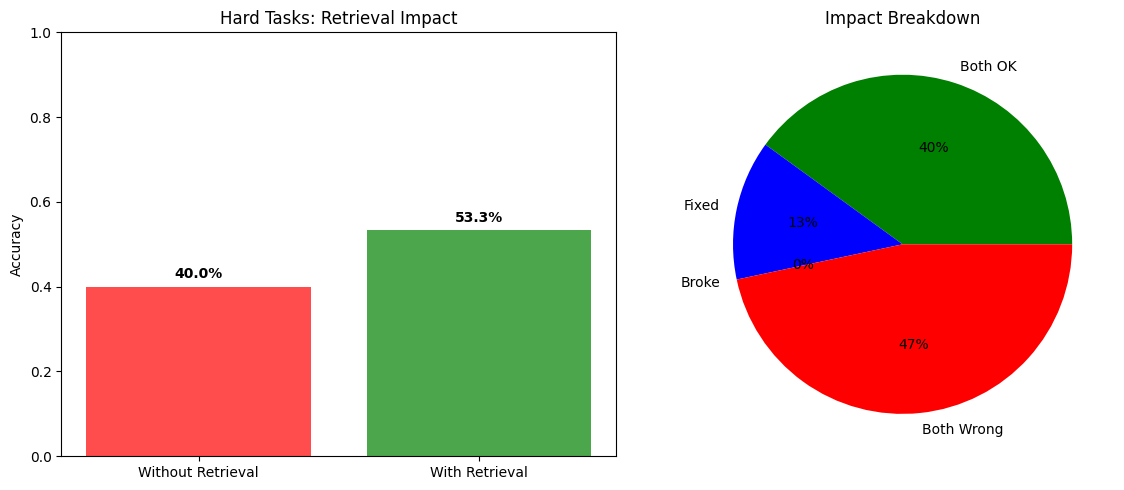

In [15]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1 = axes[0]
conditions = ['Without Retrieval', 'With Retrieval']
accuracies = [none_correct/total, ret_correct/total]
colors = ['red', 'green']
bars = ax1.bar(conditions, accuracies, color=colors, alpha=0.7)
ax1.set_ylabel('Accuracy')
ax1.set_title('Hard Tasks: Retrieval Impact')
ax1.set_ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.1%}', ha='center', fontweight='bold')

# Breakdown pie
ax2 = axes[1]
sizes = [len(both_right), len(fixed), len(broke), len(both_wrong)]
labels = ['Both OK', 'Fixed', 'Broke', 'Both Wrong']
colors = ['green', 'blue', 'orange', 'red']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%')
ax2.set_title('Impact Breakdown')

plt.tight_layout()
plt.savefig('week15_v3_hard_tasks_results.png', dpi=150)
plt.show()

In [16]:
# Final conclusion
print("="*70)
print("FINAL CONCLUSION")
print("="*70)

print(f"""
HARD TASKS (requiring specific internal knowledge):

Without retrieval: {none_correct}/{total} ({100*none_correct/total:.1f}%)
With retrieval:    {ret_correct}/{total} ({100*ret_correct/total:.1f}%)

Improvement: {ret_correct - none_correct:+d} tasks fixed
Regression:  {len(broke)} tasks broken
Net effect:  {len(fixed) - len(broke):+d}
""")

if ret_correct > none_correct + 2:
    print("CONCLUSION: Retrieval SIGNIFICANTLY helps for hard tasks!")
    print("The model cannot answer these questions without seeing the source code.")
elif ret_correct > none_correct:
    print("CONCLUSION: Retrieval provides MODEST improvement.")
elif ret_correct == none_correct:
    print("CONCLUSION: Retrieval has NO impact.")
else:
    print("CONCLUSION: Retrieval HURTS performance.")

FINAL CONCLUSION

HARD TASKS (requiring specific internal knowledge):

Without retrieval: 6/15 (40.0%)
With retrieval:    8/15 (53.3%)

Improvement: +2 tasks fixed
Regression:  0 tasks broken
Net effect:  +2

CONCLUSION: Retrieval provides MODEST improvement.


In [17]:
# Save
output = {
    'experiment': 'Week15_V3_Hard_Tasks',
    'num_tasks': len(HARD_TASKS),
    'without_retrieval': {'correct': none_correct, 'accuracy': none_correct/total},
    'with_retrieval': {'correct': ret_correct, 'accuracy': ret_correct/total},
    'fixed_by_retrieval': len(fixed),
    'broke_by_retrieval': len(broke),
    'results': results,
}

with open('week15_v3_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

print("Saved to week15_v3_results.json")

Saved to week15_v3_results.json
